<a href="https://qworld.net" target="_blank" align="left"><img src="https://gitlab.com/qworld/qeducation/qbook101/raw/main/qworld/images/header.jpg" align="left"></a>

In [ ]:
...adapted from the notes by Abuzer Yakaryilmaz

# Entanglement and Quantum Protocols

In [18]:
import IPython
import matplotlib.pyplot as plt

from qiskit.circuit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import array_to_latex, plot_histogram, plot_state_qsphere
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import Batch, QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler



# 1.0 Two Qubits System

##### A quantum system with two qubits may be represented by any of $ \ket{00}, \ket{01}, \ket{10}, or \, \ket{11}.$

We note here that this is *a very simplistic* representation (each with an amplitude of 1)!

Other forms of combination of each of the states above also exist. Ideally, what matters is the number of qubits used in the notation, and here, we are restricted to two qubits!!!


The state $ \ket{ab} $ means that

- the first qubit is in state $ \ket{a} $ and
- the second qubit is in state $ \ket{b} $,

where $ a,b \in \{0,1\} $.

$ \ket{ab} = \ket{a} \otimes \ket{b} $ (or shortly $\ket{a}\ket{b}$.

<div class="alert alert-block alert-info">
  <b>Sanity check: Which is first and which is second?</b>

The choice of first or second qubit is by convention, and it is important to know which convention
a particular context is using.

Read more on the `little-endian or big-endian` convention.

Beware of qubits counting by indexing (qubit0, qubit1).
    
</div>

## 1.1 Gate Operations: Hadamard and CNOT

### 1.1.1 Hadamard and Superposition

Suppose we think of states in **superposition**!!!

A single qubit state is either a $\ket{0}$ or a $\ket{1}$. A superposition of both could be the state " $\ket{0} + \ket{1}$ " or " $\ket{0} - \ket{1}$ "

<div class="alert alert-block alert-warning">
  <b>Sanity check: Total probability sums up to 1.</b>

In the language of Quantum Mechanics, neither of the above superposition states is **normalized**.

`Normalization requires that the sum of all probabilites sums to 1.`

Can you think of a normalized quantum state?
</div>

Neither of " $\ket{0} \pm \ket{1}$ " is normalized!

The following are examples of superpositions that are normalized:

- $\frac{1}{\sqrt{2}}\ket{0} + \frac{1}{\sqrt{2}}\ket{1}$ or written in shorthand as $\ket{+}$;
- $\frac{1}{\sqrt{2}}\ket{0} - \frac{1}{\sqrt{2}}\ket{1}$ or written in shorthand as $\ket{-}$;
- $\frac{1}{2}\ket{0} + \frac{\sqrt{3}}{2}\ket{1}$;
- $\frac{2}{\sqrt{7}}\ket{0} - \sqrt{\frac{3}{7}}\ket{1}$;  
...and many more!
  
The $\ket{+}$ and $\ket{-}$ states are well known because they are states of equal superposition (for $\ket{0}$ and $\ket{1}).$

The $\frac{1}{\sqrt{2}}$ coefficients are probability amplitudes, and the measurement probability of each outcome is the square of its amplitude.


<div class="alert alert-block alert-success">
  <b>Sanity check: Hadamard and the 50-50 effect</b>


The [Hadamard gate (H)](https://quantum.cloud.ibm.com/docs/api/qiskit/qiskit.circuit.library.HGate) takes a qubit in a definite state ($|0\rangle$ or $|1\rangle$) and puts it into an equal superposition

$$H = \frac{1}{\sqrt{2}}\begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}, \qquad H|0\rangle = \frac{1}{\sqrt{2}}\bigl(|0\rangle + |1\rangle\bigr) = |+\rangle$$

Measuring the $|+\rangle$ state gives 0 or 1 with equal probability (50% each). 


What is $H|1\rangle$?

</div>


### 1.1.2 Hadamard and Superposition (Circuit Representation using Qiskit)

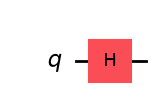

In [9]:
#Adding Hadamard to a single qubit
qc = QuantumCircuit(1)

# TODO: Add a Hadamard gate on qubit 0: H|0>
qc.h(0)

qc.draw("mpl")


##### Showing the Statevector (using Qiskit)

In [16]:
sv = Statevector(qc)
display(sv.draw("latex"))

<IPython.core.display.Latex object>

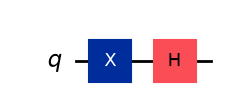

In [12]:
#Repeat for H|1>
qc1 = QuantumCircuit(1)

# TODO: Add a X gate on qubit 0 to create a |1>
qc1.x(0)
# TODO: Add a Hadamard gate on qubit 0 : H|1>
qc1.h(0)

qc1.draw("mpl")


In [17]:
sv1 = Statevector(qc1)
display(sv1.draw("latex"))

<IPython.core.display.Latex object>

## 1.2 Back to Two Qubits: on Superposition and Entanglement

A (single-qubit) quantum system can be in different superpositions (Hadamard gate only gives equal superposition) of possible single qubit states.

Following the postulates of Quantum Mechanics, a two qubits quantum system can also be in different superpositions of possible two qubit states. In general, superposition is possible for any n-qubit states.

Earlier we stated that two qubits may be represented by any of $ \ket{00}, \ket{01}, \ket{10}, or \, \ket{11}$.

Hence the following are examples of normalized two-qubits superposition:

- $\frac{1}{2}\ket{00} \pm \frac{1}{2}\ket{01} \pm \frac{1}{2}\ket{10} \pm \frac{1}{2}\ket{11}$

<div class="alert alert-block alert-success">
  <b>Sanity check: The Hadamard effect on 2 qubits</b>

    Can you understand that the above can be expanded into 24 distinct equal superpositions of all 4 possible two qubits representations?

</div>

- $\frac{2}{5}\ket{00} - \frac{\sqrt{7}}{5}\ket{01} - \frac{3}{5}\ket{10} + \frac{\sqrt{5}}{5}\ket{11}$

## 1.3 From Superposition to Entanglement

The state
$\frac{1}{\sqrt{2}}\ket{00} + \frac{1}{\sqrt{2}}\ket{01}$
is an interesting superposition of the two qubits states $\ket{00}$ and $\ket{01}$.

Also, it can easily be decomposed into a product of two distinct "one qubit" states: a $\ket{0}$ state and a $\ket{+}$.

$$\frac{1}{\sqrt{2}}\ket{00} + \frac{1}{\sqrt{2}}\ket{01} = \ket{0} \otimes \frac{\ket{0} + \ket{1}}{\sqrt{2}} = \ket{0} \otimes \ket{+}$$

All true two qubits superpositions are decomposable into products of two distinct "one qubit" states.

If it is not possible to decompose a two qubit state into product of two "one qubit" states, then we have an `entangled state`.

In general, any $n>=2$ qubit states can form entangled states.

The (four) **bell states** are common examples of maximally entangled two qubits states.

<div class="alert alert-block alert-info">
  <b>Sanity check: Entanglement is here!!!</b>

Two of the four **bell states** are the entangled states: $\frac{\ket{00} + \ket{11}}{\sqrt{2}}$ and $\frac{\ket{01} - \ket{10}}{\sqrt{2}}$

</div>

### 1.3.1 The CX (CNOT) Gate and Entanglement

The CX gate is a **two-qubit** gate. It flips the **target** qubit if and only if the **control** qubit is $\ket{1}$.

When the control is in **superposition**, something remarkable happens: the two qubits become **entangled**. Their measurement outcomes become perfectly correlated in a way that has no classical explanation.

This is purely quantum mechanical!

Let us see the CNOT gate in action using qiskit.

<div class="alert alert-block alert-success">
<b> Sanity check: CNOT in action</b>

Using the circuit below, we would try the following

1. (already given) Create a two qubit circuit, and observe the Statevector
2. Return to circuit, then apply <b>CNOT</b> to named qubits, observe the statevector again.
3. Return to circuit, put control qubit in state |1>, observe the statevector again.
4. Return to circuit, put control qubit in state |1>, then apply <b>CNOT</b>, observe the statevector again.

    `Do you observe that the target qubit is also flipped to |1>?`

5. Return to circuit, try different combinations on control and target qubits, apply <b>CNOT</b>, observe the statevector again.

</div>

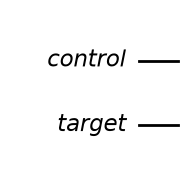

In [43]:
# visualizing CNOT in action

# Create named quantum registers
qctrl = QuantumRegister(1, 'control')
qtarg = QuantumRegister(1, 'target')

# Build the circuit using the named registers
qcnot = QuantumCircuit(qctrl, qtarg)

#TO-DO 2: Apply CNOT gate
#qcnot.cx(qctrl[0],qtarg[0])

#TO-DO 3: put control qubit in state |1>
#qcnot.x(qctrl[0])

#TO-DO 4: put control qubit in state |1>
#qcnot.x(qctrl[0])
#qcnot.cx(qctrl[0],qtarg[0])


qcnot.draw('mpl')

In [44]:
# display the Statevector
sv3 = Statevector(qcnot)
display(sv3.draw('latex'))

<IPython.core.display.Latex object>

### 1.3.2 Now let's get entangled!

When the control is in **superposition**, and CNOT is applied as before, something remarkable happens: the two qubits become **entangled**.

We can now combine Hadamard and CNOT in a remarkable way to see the two qubits entangled!

With equal superpositions (using Hadamard) and CNOT, we can create the four bell states.

Here is how to create one of them!

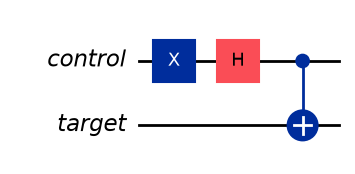

In [45]:
# Creating Bell States

# Create named quantum registers
qctrl = QuantumRegister(1, 'control')
qtarg = QuantumRegister(1, 'target')

# Build the circuit using the named registers
qbell = QuantumCircuit(qctrl, qtarg)

#TO-DO 2: create a bell state
qbell.x(qctrl[0]) 
#qbell.x(qtarg[0])

qbell.h(qctrl[0])
qbell.cx(qctrl[0],qtarg[0])


qbell.draw('mpl')

# display the Statevector
sv4 = Statevector(qbell)
display(sv4.draw('latex'))

<div class="alert alert-block alert-success">
<b>Sanity check: All Four Bell States</b>

Can you try building all 4 Bell states?  
1. $$\ket{\psi^+} = \frac{\ket{00} + \ket{11}}{\sqrt{2}}$$   
2. $$\ket{\psi^-} = \frac{\ket{00} - \ket{11}}{\sqrt{2}}$$ 
3. $$\ket{\phi^+} = \frac{\ket{01} + \ket{10}}{\sqrt{2}}$$
4. $$\ket{\phi^-} = \frac{\ket{01} - \ket{10}}{\sqrt{2}}$$

    `What combinations of gates do you need?`

</div>

# 2.0 Entanglement in action: Quantum Protocols

## 2.1 Entanglement and Superdense Coding

Suppose Asja and Balvis share two entangled qubits of the form
$$\ket{\psi^+} = \frac{\ket{00} + \ket{11}}{\sqrt{2}}$$

We are guaranteed that these qubits are entangled because of **the correlation** between them described as follows:
- If both qubits are measured, we can observe either state $\ket{00}$ or $\ket{11}$ with equal probabilities;
- If Asja secretly measures her qubit, and Balvis also secretly measures his qubit, both of them will observe the same result (of either $\ket{0}$ or $\ket{1}$.   

This is the nature of how their entangled qubits are correlated. Once Asja sees the result $\ket{0}$, it is guaranteed that Balvis will also see the result $\ket{0}$. This correlation is in the entanglement!

**Entangled qubits can be useful.**

### 2.1.1 Quantum Communication: Superdense coding

Superdense coding is a quantum communication protocol that lets you send two classical bits of information by transmitting only a single physical qubit, provided the sender and receiver share an entangled pair of qubits beforehand.


<img src="https://gitlab.com/qworld/qeducation/qbook101/raw/main/qbook101/images/ch2/superdense-coding.jpg" align="left" width="800px">